In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("urban_heat_dataset.csv")
print(df.head())

Saving urban_heat_dataset.csv to urban_heat_dataset (1).csv
   S.No  Surface Temperature (°C)  NDVI  Building Density (%)  \
0     1                        42  0.15                    90   
1     2                        39  0.22                    82   
2     3                        35  0.40                    65   
3     4                        30  0.70                    30   
4     5                        33  0.55                    45   

   Road Density (%) Heat Zone  
0                75      High  
1                68      High  
2                55    Medium  
3                20       Low  
4                35       Low  


In [ ]:
df.isnull().sum()

,0
S.No,0
Surface Temperature (°C),0
NDVI,0
Building Density (%),0
Road Density (%),0
Heat Zone,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
encoder = LabelEncoder()

df["Heat Zone"] = encoder.fit_transform(df["Heat Zone"])

In [ ]:
df.describe()

,S.No,Surface Temperature (°C),NDVI,Building Density (%),Road Density (%),Heat Zone
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,35.850000,0.406500,62.800000,51.100000,0.950000
std,5.91608,4.545385,0.212412,23.300328,21.038561,0.825578
min,1.00000,29.000000,0.100000,25.000000,18.000000,0.000000
25%,5.75000,32.750000,0.215000,43.750000,33.750000,0.000000
50%,10.50000,35.500000,0.390000,66.000000,54.500000,1.000000
75%,15.25000,39.250000,0.562500,82.750000,68.500000,2.000000
max,20.00000,44.000000,0.750000,98.000000,85.000000,2.000000


In [ ]:
print(np.mean(df["Surface Temperature (°C)"]))

35.85


In [ ]:
print(np.max(df["Surface Temperature (°C)"]))

44


In [ ]:
df.corr(numeric_only=True)

,S.No,Surface Temperature (°C),NDVI,Building Density (%),Road Density (%),Heat Zone
S.No,1.000000,-0.004893,0.059264,-0.036272,-0.030446,0.080819
Surface Temperature (°C),-0.004893,1.000000,-0.984526,0.984659,0.980936,-0.549097
NDVI,0.059264,-0.984526,1.000000,-0.997746,-0.995232,0.455148
Building Density (%),-0.036272,0.984659,-0.997746,1.000000,0.997155,-0.438317
Road Density (%),-0.030446,0.980936,-0.995232,0.997155,1.000000,-0.408775
Heat Zone,0.080819,-0.549097,0.455148,-0.438317,-0.408775,1.000000


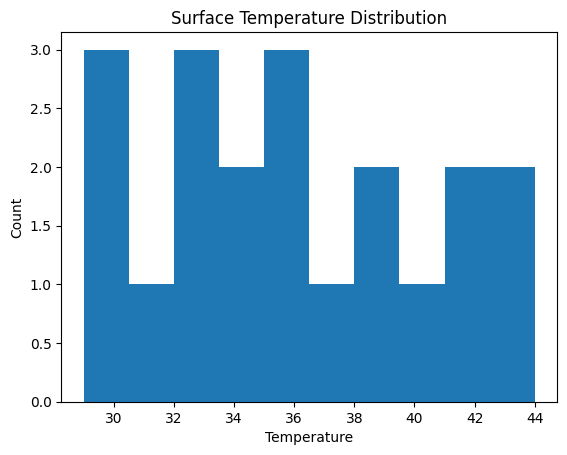

In [ ]:
plt.hist(df["Surface Temperature (°C)"])

plt.title("Surface Temperature Distribution")

plt.xlabel("Temperature")

plt.ylabel("Count")

plt.show()

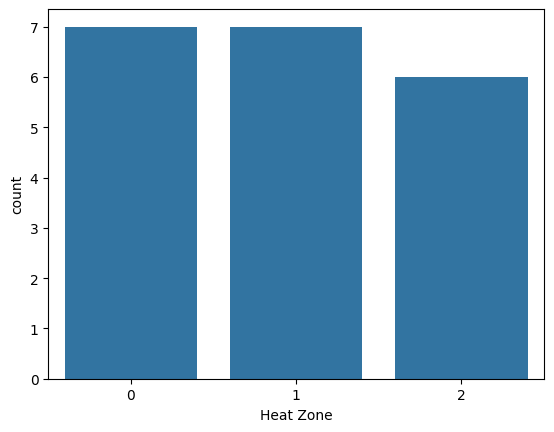

In [ ]:
sns.countplot(x="Heat Zone", data=df)
plt.show()

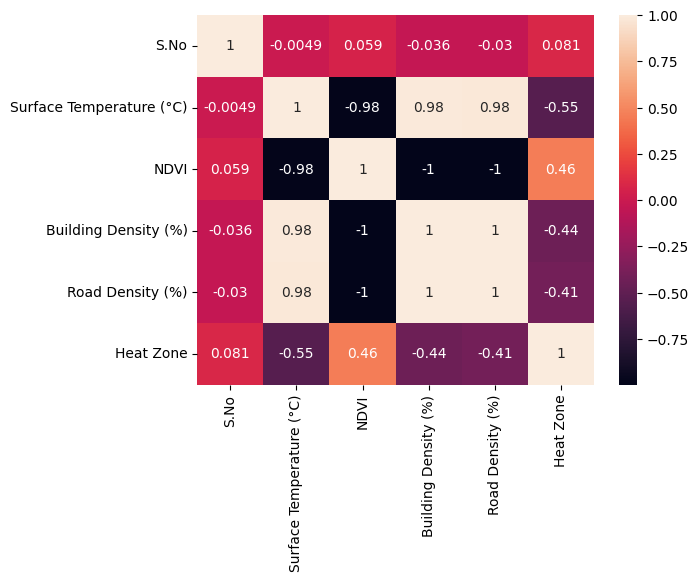

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

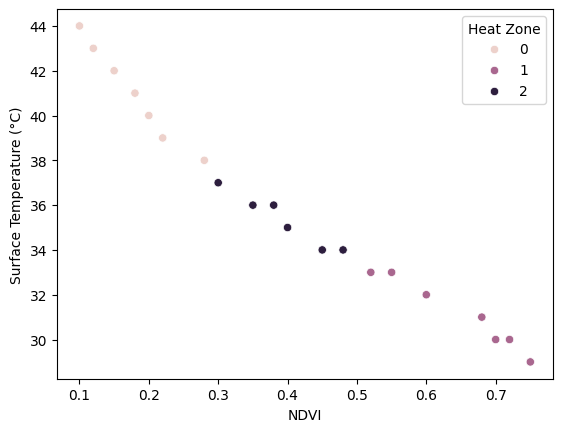

In [ ]:
sns.scatterplot(x="NDVI",

                y="Surface Temperature (°C)",

                hue="Heat Zone",

                data=df)

plt.show()

In [ ]:
X = df.drop(["Heat Zone", "S.No"], axis=1)
y = df["Heat Zone"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42
)

In [ ]:
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(4,)))

model.add(Dense(8, activation='relu'))

model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(

optimizer='adam',

loss='sparse_categorical_crossentropy',

metrics=['accuracy']
)

In [ ]:
model.fit(

X_train,

y_train,

epochs=50,

batch_size=4
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0706 
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0650 
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0669 
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0621 
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 1.0604 
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0596 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0568 
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0553 
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0533 
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 1.0524 
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0512 
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0493 
E

In [ ]:
prediction = model.predict(X_test)

prediction = np.argmax(prediction, axis=1)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[2 2 2 2]


In [ ]:
print("Accuracy =",accuracy_score(y_test,prediction))

Accuracy = 0.25


In [ ]:
print(confusion_matrix(y_test,prediction))

[[0 3]
 [0 1]]


In [ ]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           2       0.25      1.00      0.40         1

    accuracy                           0.25         4
   macro avg       0.12      0.50      0.20         4
weighted avg       0.06      0.25      0.10         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
new_data = np.array([[43,0.12,92,78]])

prediction = model.predict(new_data)

prediction = np.argmax(prediction)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2
